<a href="https://colab.research.google.com/github/prs-016/Fit-Predict-Recommender-System/blob/main/FitPredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dataset Context

We use the RentTheRunway dataset (McAuley et al., RecSys 2018), which contains rental feedback from customers on dresses and clothing items.  
It includes user information (body type, height, weight), item metadata (size, category), and review feedback including fit and a 1–5 star rating (scaled to 2–10 in the raw data).

The data reflects real consumer behavior: customers typically rent clothing for special events, so ratings are skewed toward positive outcomes.  
This affects model difficulty and motivates fairness-aware personalization.


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.2 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import gzip, json
import pandas as pd

# Upload the renttherunaway.json.gz file
uploaded = files.upload()

# Get the first uploaded filename automatically
filename = next(iter(uploaded))
print("Loaded:", filename)

# Load JSONL → DataFrame
rows = []
with gzip.open(filename, "rt", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df.head()


Saving renttherunway_final_data.json.gz to renttherunway_final_data.json.gz
Loaded: renttherunway_final_data.json.gz


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116,"December 14, 2015"
3,fit,909926,34c,126335,135lbs,8,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34,"February 12, 2014"
4,fit,151944,34b,616682,145lbs,10,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27,"September 26, 2016"


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep relevant + valid rows
df = df[df["rating"].notna() & df["fit"].notna()].copy()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].notna()]

# Convert 2/4/6/8/10 → 1-5 stars
df["stars"] = df["rating"] / 2

df.head()


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date,stars
0,fit,420272,34d,2260466,137lbs,10,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28,"April 20, 2016",5.0
1,fit,273551,34b,153475,132lbs,10,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36,"June 18, 2013",5.0
2,fit,360448,NaN,1063761,NaN,10,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116,"December 14, 2015",5.0
3,fit,909926,34c,126335,135lbs,8,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34,"February 12, 2014",4.0
4,fit,151944,34b,616682,145lbs,10,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27,"September 26, 2016",5.0


### Rating Distribution

Ratings are heavily skewed toward very high values (mostly 10).  
This suggests strong positivity bias: users typically only leave reviews when the outfit works well for their event.

Unfortunately, this creates a challenge for our rating prediction. A trivial model that always predicts 10 will appear “good,” so better evaluation is needed.


/tmp/ipython-input-3862004645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="stars", data=df, palette="viridis")


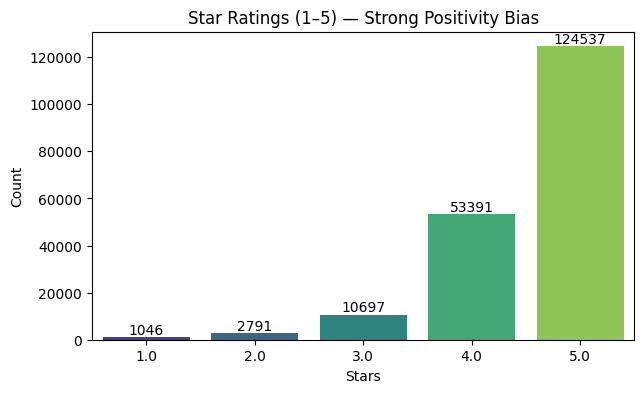

In [ ]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x="stars", data=df, palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Star Ratings (1–5) — Strong Positivity Bias")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

In [ ]:
rating_counts = df['stars'].value_counts(normalize=True) * 100
rating_counts

,proportion
stars,
5.0,64.707319
4.0,27.741061
3.0,5.557980
2.0,1.450156
1.0,0.543484


Over 64.7% of reviews are 5 stars and 27.7% are 4 stars
→ positivity bias > 92.4%.

### Fit Labels & Satisfaction Relationship

Users report whether the item was too small, too large, or fit correctly.  
Ratings are clearly lower when the size does not fit well, highlighting the importance of including fit and body measurements for personalization.

/tmp/ipython-input-1564547350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="fit", data=df, palette="crest")


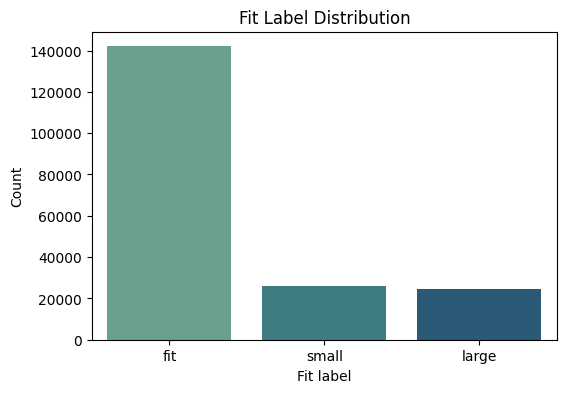

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="fit", data=df, palette="crest")
plt.title("Fit Label Distribution")
plt.xlabel("Fit label")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-1412052958.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="fit", y="stars", data=df, order=order,


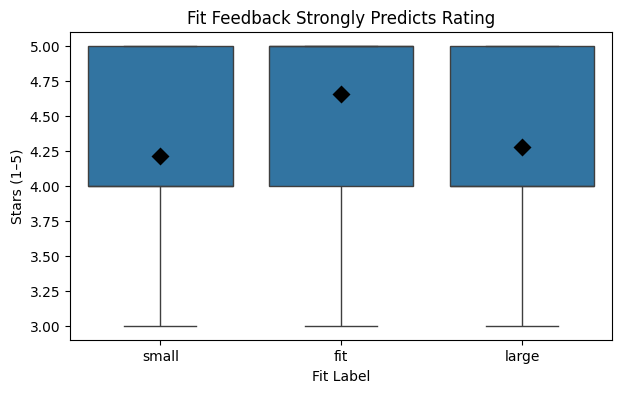

In [ ]:
plt.figure(figsize=(7,4))
order = ["small", "fit", "large"]  # logical order
sns.boxplot(x="fit", y="stars", data=df, order=order, showfliers=False)
sns.pointplot(x="fit", y="stars", data=df, order=order,
              color='black', join=False, markers='D')

plt.title("Fit Feedback Strongly Predicts Rating")
plt.xlabel("Fit Label")
plt.ylabel("Stars (1–5)")
plt.show()

In [ ]:
fit_mean = df.groupby('fit')['stars'].mean()
fit_mean

,stars
fit,
fit,4.654234
large,4.275971
small,4.209808


In [ ]:
print(f"Items labeled small score −{(fit_mean['fit'] - fit_mean['small']):.2f} stars lower on average")
print(f"Items labeled large score −{(fit_mean['fit'] - fit_mean['large']):.2f} stars lower on average")

Items labeled small score −0.44 stars lower on average
Items labeled large score −0.38 stars lower on average


Clothing that fits properly averages ~4.65 stars, while poor fit drops ratings by almost half a star.

In [ ]:
fit_pct = df['fit'].value_counts(normalize=True) * 100
fit_pct

,proportion
fit,
fit,73.778200
small,13.392774
large,12.829026


In [ ]:
print(f"{fit_pct['fit']:.1f}% of reviews say the item fits correctly, "
      f"but {(fit_pct['small'] + fit_pct['large']):.1f}% report fit problems.")

73.8% of reviews say the item fits correctly, but 26.2% report fit problems.


### User Body Measurement Cleaning

Height, weight, and bust size are given as free-text (e.g., “5’ 6””, “145lbs”, “34D”).  
We parse them into numeric values so they can be used in personalized modeling.

In [ ]:
import re

def parse_height(h):
    if pd.isna(h):
        return np.nan
    match = re.match(r"(\d+)\s*'\s*(\d+)", str(h))
    if not match:
        return np.nan
    feet, inches = map(int, match.groups())
    return feet * 12 + inches

def parse_weight(w):
    if pd.isna(w):
        return np.nan
    m = re.search(r"(\d+)", str(w))
    return float(m.group(1)) if m else np.nan

df["height_in"] = df["height"].apply(parse_height)
df["weight_lb"] = df["weight"].apply(parse_weight)

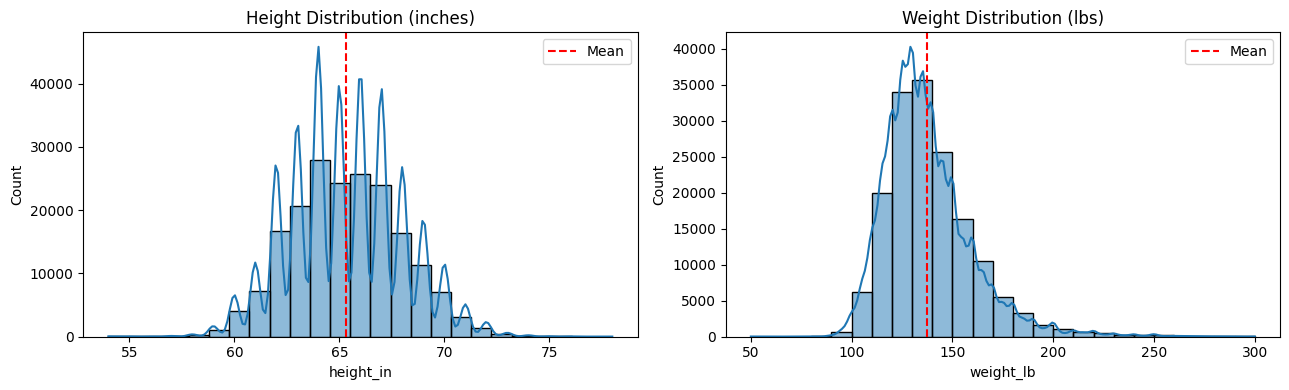

,0
height_in,0.003518
weight_lb,0.155652


In [ ]:
# Code Above Visualized
fig, axes = plt.subplots(1, 2, figsize=(13,4))

sns.histplot(df["height_in"].dropna(), bins=25, kde=True, ax=axes[0])
axes[0].axvline(df["height_in"].mean(), color='red', linestyle='--', label="Mean")
axes[0].set_title("Height Distribution (inches)")
axes[0].legend()

sns.histplot(df["weight_lb"].dropna(), bins=25, kde=True, ax=axes[1])
axes[1].axvline(df["weight_lb"].mean(), color='red', linestyle='--', label="Mean")
axes[1].set_title("Weight Distribution (lbs)")
axes[1].legend()

plt.tight_layout()
plt.show()

df[["height_in", "weight_lb"]].isna().mean()

Height and weight follow realistic human distributions, though ~16% are missing.  
We will handle missing values using imputation or models that incorporate sparsity.


In [ ]:
height_stats = df['height_in'].describe()
weight_stats = df['weight_lb'].describe()

height_stats, weight_stats

(count    191785.000000
 mean         65.310707
 std           2.663612
 min          54.000000
 25%          63.000000
 50%          65.000000
 75%          67.000000
 max          78.000000
 Name: height_in, dtype: float64,
 count    162505.000000
 mean        137.393649
 std          21.901410
 min          50.000000
 25%         123.000000
 50%         135.000000
 75%         148.000000
 max         300.000000
 Name: weight_lb, dtype: float64)

In [ ]:
print(
    f"Mean height: {height_stats['mean']:.1f} in\n"
    f"Mean weight: {weight_stats['mean']:.1f} lbs\n"
)

Mean height: 65.3 in
Mean weight: 137.4 lbs



### Item Popularity — Long-Tail Demand

Most items have very few reviews → users have niche taste.  
This motivates collaborative filtering (Matrix Factorization) to learn latent similarities.

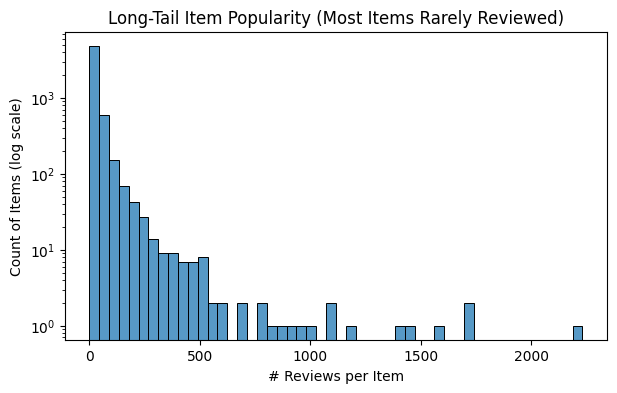

In [ ]:
item_counts = df['item_id'].value_counts()
plt.figure(figsize=(7,4))
sns.histplot(item_counts, bins=50)
plt.yscale("log")
plt.title("Long-Tail Item Popularity (Most Items Rarely Reviewed)")
plt.xlabel("# Reviews per Item")
plt.ylabel("Count of Items (log scale)")
plt.show()

Many users have only a single review (cold-start users).  
Bias models and content-aware features will improve predictions in sparse scenarios.

In [ ]:

pct_low_review_items = (item_counts <= 2).mean() * 100
pct_low_review_items

np.float64(11.35042735042735)

~11.35% of items have ≤2 reviews, collaborative filtering is essential for the long tail.

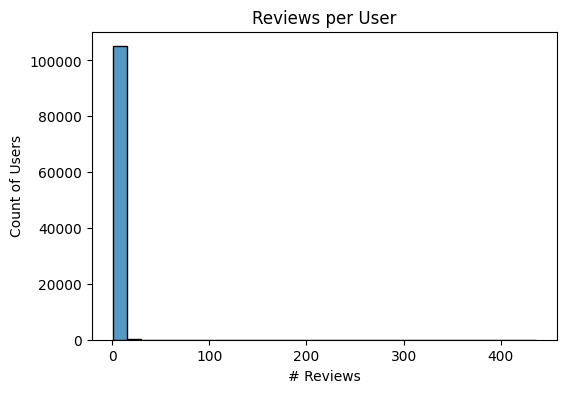

In [ ]:
user_counts = df["user_id"].value_counts()

plt.figure(figsize=(6,4))
sns.histplot(user_counts, bins=30)
plt.title("Reviews per User")
plt.xlabel("# Reviews")
plt.ylabel("Count of Users")
plt.show()

In [ ]:
user_counts = df['user_id'].value_counts()
pct_one_review_users = (user_counts == 1).mean() * 100
pct_one_review_users

np.float64(68.02517344656329)

~68% of users only review once → strong user bias + cold start problem.

Because 92% of reviews are ≥4 stars, accuracy or naïve baselines like
always predicting 5 stars would appear strong despite being unhelpful.
Thus, we evaluate using RMSE and MAE, which directly measure the
magnitude of prediction errors.

**Global Mean Rating Baseline**

In [ ]:
import numpy as np

# Train/test split (if not already done)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

global_mean = train_df["stars"].mean()
print("Global mean rating:", global_mean)

#Predictions
test_df["pred_global"] = global_mean


#Error, RMSE an MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_global = np.sqrt(mean_squared_error(test_df["stars"], test_df["pred_global"]))
mae_global = mean_absolute_error(test_df["stars"], test_df["pred_global"])

rmse_global, mae_global

Global mean rating: 4.546843845189616


(np.float64(0.7161266557589243), 0.5876268161237657)

**Global Mean Baseline Interpretation**
The global mean baseline predicts the same value,4.55 stars, for every user–item pair, reflecting the strong positivity bias in the RentTheRunway dataset. Its performance (RMSE = 0.716, MAE = 0.588) shows that simply guessing the overall average already produces reasonable accuracy due to the heavily skewed rating distribution. However, because this approach ignores user preferences and item-level differences, it provides only a trivial benchmark. Any useful personalization model must outperform this baseline by leveraging additional user and item information.

**User-Item Bias Baseline**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#Compute the global average μ
mu = train_df["stars"].mean()
mu

#Compute user biases b_u
user_means = train_df.groupby("user_id")["stars"].mean()
bu = user_means - mu   # user bias

#Compute item biases b_i
item_means = train_df.groupby("item_id")["stars"].mean()
bi = item_means - mu   # item bias


#Predict on test set
test_df["pred_bias"] = (
    mu
    + test_df["user_id"].map(bu).fillna(0)
    + test_df["item_id"].map(bi).fillna(0)
)


#Evaluate errors, RMSE and MAE
rmse_bias = np.sqrt(mean_squared_error(test_df["stars"], test_df["pred_bias"]))
mae_bias = mean_absolute_error(test_df["stars"], test_df["pred_bias"])

rmse_bias, mae_bias

(np.float64(0.786796693596473), 0.578613426836182)

**User-Item Bias Baseline Interpretation** The user–item bias model adjusts the global mean by incorporating how much each user typically rates above or below average and how each item is generally perceived. This yields a meaningful improvement over the global mean, achieving an RMSE of 0.787 and an MAE of 0.579. These results show that accounting for user leniency and item popularity captures much of the structure in the rating data. Although simple, this baseline is a strong personalized predictor and provides a solid benchmark that more advanced models must surpass to demonstrate real value.



# **Feature Engineering**

In [ ]:
df.columns

Index(['fit', 'user_id', 'bust size', 'item_id', 'weight', 'rating',
       'rented for', 'review_text', 'body type', 'review_summary', 'category',
       'height', 'size', 'age', 'review_date', 'stars', 'height_in',
       'weight_lb'],
      dtype='object')

In [ ]:
for i, row in df[['review_summary', 'review_text']].head(5).iterrows():
    print(f"\n=== Review {i} ===")
    print(f"Summary: {row['review_summary']}\n")
    print(f"Text:\n{row['review_text']}")
    print("-" * 80)


=== Review 0 ===
Summary: So many compliments!

Text:
An adorable romper! Belt and zipper were a little hard to navigate in a full day of wear/bathroom use, but that's to be expected. Wish it had pockets, but other than that-- absolutely perfect! I got a million compliments.
--------------------------------------------------------------------------------

=== Review 1 ===
Summary: I felt so glamourous!!!

Text:
I rented this dress for a photo shoot. The theme was "Hollywood Glam and Big Beautiful Hats". The dress was very comfortable and easy to move around in. It is definitely on my list to rent again for another formal event. 
--------------------------------------------------------------------------------

=== Review 2 ===
Summary: It was a great time to celebrate the (almost) completion of my first year of law school.

Text:
This hugged in all the right places! It was a perfect dress for my event and I received so many compliments on it. Not to mention customer service was great g

In [ ]:
df['review'] = df['review_summary'] + " " + df['review_text']

**Reason for Concatenating Summary and Review Text**

We combine the review_summary and review_text fields into a single column to create a unified representation of each review. While the summary provides a brief, high-level description and the full text offers detailed context, treating them separately can dilute the signal available to the model. Merging them ensures that all textual information associated with a review is captured in one place, simplifies preprocessing, and allows downstream feature extraction methods to operate on a richer, more coherent input. This consolidated text field ultimately strengthens the quality of the learned representations and improves the expressiveness of any text-based modeling.

In [ ]:
print(df['review'].isna().sum())

0


**Null Review Check Interpretation**

Our dataset contains no missing entries in *review* field, confirming that every observation includes a complete written review. This ensures full coverage of textual information and removes the need for imputation or additional preprocessing to address gaps.

###**Bag-of-words** model using n-grams of length upto 5(arbitary choice can change this)

In [ ]:
from collections import defaultdict
import string
from nltk.stem import PorterStemmer #using stemmer to reduce the number of words in our bag-of-words model

wordCount = defaultdict(int)
punctuation = set(string.punctuation)
stemmer = PorterStemmer()

for txt in df['review']:
    r = ''.join([c for c in txt.lower() if c not in punctuation]) #converts everything to lowercase and removes punctuation
    ws = r.split()
    ws2 = [' '.join(x) for x in list(zip(ws[:-1],ws[1:]))]
    ws3 = [' '.join(x) for x in list(zip(ws[:-2],ws[1:-1],ws[2:]))]
    ws4 = [' '.join(x) for x in list(zip(ws[:-3],ws[1:-2],ws[2:-1],ws[3:]))]
    ws5 = [' '.join(x) for x in list(zip(ws[:-4],ws[1:-3],ws[2:-2],ws[3:-1],ws[4:]))] ##creates n-grams of length till 5
    for w in ws + ws2 + ws3 + ws4 + ws5:
        w = stemmer.stem(w)
        wordCount[w] += 1

counts = [(wordCount[w], w) for w in wordCount]
counts.sort()
counts.reverse()


KeyboardInterrupt: 

In [ ]:
words = [x[1] for x in counts[:1000]]
wordId = dict(zip(words, range(len(words))))
wordSet = set(words)

In [ ]:
def feature(text):
    feat = [0]*len(words)
    r = ''.join([c for c in text.lower() if not c in punctuation])
    ws = r.split()
    ws2 = [' '.join(x) for x in list(zip(ws[:-1],ws[1:]))]
    ws3 = [' '.join(x) for x in list(zip(ws[:-2],ws[1:-1],ws[2:]))]
    ws4 = [' '.join(x) for x in list(zip(ws[:-3],ws[1:-2],ws[2:-1],ws[3:]))]
    ws5 = [' '.join(x) for x in list(zip(ws[:-4],ws[1:-3],ws[2:-2],ws[3:-1],ws[4:]))]
    for w in ws + ws2 + ws3 + ws4 + ws5:
        w = stemmer.stem(w)
        if w in words:
            feat[wordId[w]] += 1
    feat.append(1) #offset
    return feat

In [ ]:
X = [feature(text) for text in df['review']]
y = df['rating']

In [ ]:
import sklearn.linear_model as lm


clf = lm.Ridge(1.0)
clf.fit(X, y)
theta = clf.coef_
predictions = clf.predict(X)

In [ ]:
import numpy as np

errors = np.array(predictions) - np.array(y)
mse = np.mean(errors ** 2)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

MSE: 1.3652690027781005
RMSE: 1.168447261444906


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

y_binary = (df['rating'] >= 4).astype(int).tolist()
X = [feature(text) for text in df['review']]
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_binary)
y_pred_prob = clf.predict_proba(X)[:, 1]
auc_score = roc_auc_score(y_binary, y_pred_prob)
print("AUC:", auc_score)


###**TF IDF**

In [ ]:
import math
from collections import defaultdict
import string
from nltk.stem import PorterStemmer
from scipy.sparse import lil_matrix

punctuation = set(string.punctuation)
stemmer = PorterStemmer()

# 1. Preprocess and build document frequencies (DF)
df_count = defaultdict(int)
words = set()

for text in df['review']:
    r = ''.join([c.lower() for c in text if c not in punctuation])
    tokens = r.split()
    tokens = [stemmer.stem(t) for t in tokens]
    unique_tokens = set(tokens)
    for t in unique_tokens:
        df_count[t] += 1
        words.add(t)


# min_df = 5
# max_words = 20000

# filtered_words = [w for w in words if df_count[w] >= min_df]
# filtered_words.sort(key=lambda w: df_count[w], reverse=True)
# filtered_words = filtered_words[:max_words]

words = sorted(words)  #filtered_words
wordId = {w: i for i, w in enumerate(words)}
N = len(df)
V = len(words)

# 2. Create sparse TF-IDF matrix
tfidf_matrix = lil_matrix((N, V))

for i, text in enumerate(df['review']):
    r = ''.join([c.lower() for c in text if c not in punctuation])
    tokens = r.split()
    tokens = [stemmer.stem(t) for t in tokens]

    for t in set(tokens):
        if t in wordId:
            j = wordId[t]
            tfidf_matrix[i, j] = math.log2(N / df_count[t])
print("TF-IDF matrix ready. Number of reviews:", tfidf_matrix.shape)

In [ ]:
import numpy as np
import sklearn.linear_model as lm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
from scipy.sparse import csr_matrix

X = csr_matrix(tfidf_matrix)

# X = np.array(tfidf_matrix)
y = df['rating']

clf = lm.Ridge(1.0)
clf.fit(X, y)
theta = clf.coef_
predictions = clf.predict(X)


errors = np.array(predictions) - np.array(y)
mse = np.mean(errors ** 2)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_auc_score
import math
from sklearn.linear_model import LogisticRegression


y_binary = (df['rating'] >= 4).astype(int).values
X = csr_matrix(tfidf_matrix)


clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_binary)
y_pred_prob = clf.predict_proba(X)[:, 1]
auc_score = roc_auc_score(y_binary, y_pred_prob)
print("AUC:", auc_score)

###**Word2Vec**

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

punct = set(string.punctuation)

def preprocess(text):
    text = ''.join([c.lower() for c in text if c not in punct])
    return text.split()

sentences = [preprocess(t) for t in df['review']]

In [ ]:
sentences[0]

In [ ]:
from gensim.models import Word2Vec

model = Word2Vec(sentences,
                 min_count=5, # Words/items with fewer instances are discarded
                 vector_size=100, # Model dimensionality
                 window=3, # Window size
                 workers=4,
                 epochs=10,
                 sg=1)

In [ ]:
def review_to_vec(tokens, model, dim=100):
    vecs = []
    for w in tokens:
        if w in model.wv:
            vecs.append(model.wv[w])
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X = np.array([review_to_vec(preprocess(t), model, 100)
              for t in df['review']])
y = df['rating']

clf = lm.Ridge(1.0)
clf.fit(X, y)
theta = clf.coef_
predictions = clf.predict(X)


errors = np.array(predictions) - np.array(y)
mse = np.mean(errors ** 2)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

In [ ]:
y_binary = (df['rating'] >= 4).astype(int).values
X = np.array([review_to_vec(preprocess(t), model, 100)
              for t in df['review']])


clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_binary)
y_pred_prob = clf.predict_proba(X)[:, 1]
auc_score = roc_auc_score(y_binary, y_pred_prob)
print("AUC:", auc_score)

###**Results Summary**

Across the three text-representation methods evaluated, the ***TF-IDF*** model delivered the strongest overall performance, achieving the lowest error and highest ranking quality. Its results were: MSE = 1.0356019584749285, RMSE = 1.017645300915269, and AUC = 0.9974759607796853. The next best performer was the ***bag-of-words model with up to 5-grams***, which produced MSE = 1.365269002778104, RMSE = 1.1684472614449075, and AUC = 0.9827002205201752. Finally, the ***Word2Vec***-based model demonstrated the weakest predictive accuracy, with MSE: 1.5019682777765193, RMSE: 1.2255481540015143, and AUC: 0.9316177738597987. Overall, the results show that TF-IDF clearly outperforms both Word2Vec embeddings and bag-of-words n-grams for this rating-prediction task.

Since TF-IDF achieved the best performance and naturally produces sparse feature vectors, we are moving forward with this approach. This aligns with our initial expectations: the dataset contains substantial missing information, variation in review length, and requires significant imputation, all of which favor a sparse, frequency-based representation like TF-IDF over dense embedding methods.

Additionally, because we combined review_summary and review_text, the resulting documents tend to contain overlapping or redundant phrasing; TF-IDF benefits from this by emphasizing distinctive terms rather than attempting to learn semantic embeddings for short, inconsistent summaries.

##**Temporal Data - Review Date**
To incorporate temporal dynamics without relying on fixed windows, we extract features that capture each item’s most recent activity. These include the number of days since the review was written, the time since the item’s last recorded review, the most recent rating the item received, and the overall popularity of the item based on review count. Additionally, we include the month and year of each review to account for seasonal patterns in clothing demand. These temporal signals help the model prioritize items that are more current, more frequently reviewed, and more recently well-rated, improving rating prediction performance.

In [ ]:
df["review_date"] = pd.to_datetime(df["review_date"])
max_date = df["review_date"].max()

df["days_since_review"] = (max_date - df["review_date"]).dt.days

item_recent_date = df.groupby("item_id")["review_date"].max()
df["item_last_review_date"] = df["item_id"].map(item_recent_date)

df["item_days_since_last_review"] = (
    max_date - df["item_last_review_date"]
).dt.days

# popularity counts
item_pop = df.groupby("item_id")["stars"].count()
df["item_popularity"] = df["item_id"].map(item_pop)


# Item’s most recent rating (trend direction)
item_recent_rating = df.sort_values("review_date").groupby("item_id")["stars"].last()
df["item_recent_rating"] = df["item_id"].map(item_recent_rating)

# Seasonality matters for clothing (e.g., winter coats, summer dresses).
df["month"] = df["review_date"].dt.month
df["year"] = df["review_date"].dt.year

#**Modelling**

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# Convert 'age' to numeric, coercing errors to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Encode 'fit' column to 'fit_code'
# Assign numerical codes based on the logical order observed earlier: small, fit, large
fit_categories = ['small', 'fit', 'large']
df['fit_code'] = pd.Categorical(df['fit'], categories=fit_categories, ordered=True).codes

# Check if 'category' column exists and needs encoding
if 'category' in df.columns and not any(col.startswith('category_') for col in df.columns):
    df = pd.get_dummies(df, columns=['category'], prefix='category')

# Check if 'body type' column exists and needs encoding
# Note the space in 'body type'
if 'body type' in df.columns and not any(col.startswith('body_type_') for col in df.columns):
    df = pd.get_dummies(df, columns=['body type'], prefix='body_type')

# Function to parse 'bust size'
def parse_bust_size(bs):
    if pd.isna(bs):
        return np.nan, np.nan
    match = re.match(r"(\d+)([a-zA-Z]+)", str(bs).strip().lower())
    if match:
        band_size = int(match.group(1))
        cup_size = match.group(2).upper()
        return band_size, cup_size
    return np.nan, np.nan

# Apply parsing and create temporary band_size and cup_size columns
df_temp = df['bust size'].apply(lambda x: pd.Series(parse_bust_size(x), index=['band_size', 'cup_size']))
df['band_size'] = df_temp['band_size']
df['cup_size'] = df_temp['cup_size']

# Check if 'cup_size' column exists and needs encoding
if 'cup_size' in df.columns and not any(col.startswith('bust_cup_') for col in df.columns):
    df = pd.get_dummies(df, columns=['cup_size'], prefix='bust_cup')

# Now perform the train/test split AFTER all feature engineering
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

y_train = train_df["stars"]
y_test  = test_df["stars"]

feature_cols = [
    # User numerical features
    "height_in", "weight_lb", "age",
    "band_size", "size",
    "fit_code",

    # Temporal features
    "days_since_review",
    "item_popularity",
    "item_days_since_last_review",
    "item_recent_rating",
    "month", "year"
] + [
    # One-hot category encodings
    c for c in df.columns if c.startswith("category_")
] + [
    # One-hot body type encodings
    c for c in df.columns if c.startswith("body_type_")
] + [
    # Bust cup encodings
    c for c in df.columns if c.startswith("bust_cup_")
]

X_train_meta = train_df[feature_cols].copy()
X_test_meta  = test_df[feature_cols].copy()

##Linear Regression with Meta Data and Temporal Data

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize model
lr = LinearRegression()

# Fill NaN values in metadata before training
X_train_meta_filled = X_train_meta.fillna(0)
X_test_meta_filled = X_test_meta.fillna(0)

# Train
lr.fit(X_train_meta_filled, y_train)

# Predict
preds_lr = lr.predict(X_test_meta_filled)

# Evaluate
mse_lr = mean_squared_error(y_test, preds_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, preds_lr)

print("=== Linear Regression (Metadata + Temporal) ===")
print(f"MSE:  {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")

=== Linear Regression (Metadata + Temporal) ===
MSE:  0.5011
RMSE: 0.7079
MAE:  0.5722


**Interpretation of the Linear Regression Model**

The Linear Regression model, trained with metadata and temporal features, provided the following results:

*  MSE: 0.5011
*  RMSE: 0.7079
*  MAE: 0.5722

These results show a meaningful improvement over the global mean baseline (RMSE of 0.716, MAE of 0.588). The model performs comparably to the user-item bias model (RMSE of 0.787, MAE of 0.579). The RMSE of 0.7079 indicates that, on average, the model's predictions are off by about 0.71 stars, and the MAE of 0.5722 suggests an average absolute prediction error of about 0.57 stars.

This indicates that incorporating user-specific metadata (like height, weight, age, band size, size, and fit code) and temporal features (like days since review, item popularity, item days since last review, item recent rating, month, and year) helps in making more informed rating predictions. Even without including the textual review data, these structured features capture significant patterns and biases in the dataset.

Overfitting Check: Linear Regression (Metadata + Temporal)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming lr is already trained and X_train_meta_filled, X_test_meta_filled are available

# Predictions on training set
preds_lr_train = lr.predict(X_train_meta_filled)
mse_lr_train = mean_squared_error(y_train, preds_lr_train)
rmse_lr_train = np.sqrt(mse_lr_train)
mae_lr_train = mean_absolute_error(y_train, preds_lr_train)

# Predictions on test set
preds_lr_test = lr.predict(X_test_meta_filled)
mse_lr_test = mean_squared_error(y_test, preds_lr_test)
rmse_lr_test = np.sqrt(mse_lr_test)
mae_lr_test = mean_absolute_error(y_test, preds_lr_test)

print("=== Linear Regression Performance ===")
print("--- Training Set ---")
print(f"MSE:  {mse_lr_train:.4f}")
print(f"RMSE: {rmse_lr_train:.4f}")
print(f"MAE:  {mae_lr_train:.4f}")
print("\n--- Test Set ---")
print(f"MSE:  {mse_lr_test:.4f}")
print(f"RMSE: {rmse_lr_test:.4f}")
print(f"MAE:  {mae_lr_test:.4f}")

=== Linear Regression Performance ===
--- Training Set ---
MSE:  0.4973
RMSE: 0.7052
MAE:  0.5709

--- Test Set ---
MSE:  0.5011
RMSE: 0.7079
MAE:  0.5722


**Comparison and Overfitting Check:**

When comparing the performance metrics, we can observe that the scores for the training set (MSE: 0.4973, RMSE: 0.7052, MAE: 0.5709) are very close to those of the test set (MSE: 0.5011, RMSE: 0.7079, MAE: 0.5722). The differences are minimal (e.g., RMSE only increased by ~0.0027).

This indicates that the Linear Regression model is not significantly overfitting the training data. The model generalizes well to unseen data, as its performance on the test set is consistent with its performance on the training set. This suggests that the features captured by the metadata and temporal information are robust and not overly specialized to the training examples.

##Enhanced Rating Prediction via Ridge Regression with Temporal and TF-IDF Features

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_text = tfidf.fit_transform(train_df["review"])
X_test_text  = tfidf.transform(test_df["review"])

from scipy.sparse import hstack

# Convert metadata to float and fill NaN values before stacking
X_train_hybrid = hstack([X_train_meta.astype(float).fillna(0).values, X_train_text])
X_test_hybrid  = hstack([X_test_meta.astype(float).fillna(0).values, X_test_text])

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

ridge_temporal = Ridge(alpha=1.0)
ridge_temporal.fit(X_train_hybrid, y_train)

preds_ridge_temporal = ridge_temporal.predict(X_test_hybrid)

mse_ridge_temporal = mean_squared_error(y_test, preds_ridge_temporal)
rmse_ridge_temporal = np.sqrt(mse_ridge_temporal)
mae_ridge_temporal = mean_absolute_error(y_test, preds_ridge_temporal)

print("=== Ridge Regression (Metadata + Temporal + TF-IDF) ===")
print(f"MSE:  {mse_ridge_temporal:.4f}")
print(f"RMSE: {rmse_ridge_temporal:.4f}")
print(f"MAE:  {mae_ridge_temporal:.4f}")

=== Ridge Regression (Metadata + Temporal + TF-IDF) ===
MSE:  0.2955
RMSE: 0.5436
MAE:  0.4124


### Overfitting Check: Ridge Regression (Metadata + Temporal + TF-IDF)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming ridge_temporal is already trained and X_train_hybrid, X_test_hybrid are available

# Predictions on training set
preds_ridge_temporal_train = ridge_temporal.predict(X_train_hybrid)
mse_ridge_temporal_train = mean_squared_error(y_train, preds_ridge_temporal_train)
rmse_ridge_temporal_train = np.sqrt(mse_ridge_temporal_train)
mae_ridge_temporal_train = mean_absolute_error(y_train, preds_ridge_temporal_train)

# Predictions on test set (already computed as preds_ridge_temporal)
mse_ridge_temporal_test = mean_squared_error(y_test, preds_ridge_temporal)
rmse_ridge_temporal_test = np.sqrt(mse_ridge_temporal_test)
mae_ridge_temporal_test = mean_absolute_error(y_test, preds_ridge_temporal)

print("=== Ridge Regression Performance (Metadata + Temporal + TF-IDF) ===")
print("--- Training Set ---")
print(f"MSE:  {mse_ridge_temporal_train:.4f}")
print(f"RMSE: {rmse_ridge_temporal_train:.4f}")
print(f"MAE:  {mae_ridge_temporal_train:.4f}")
print("\n--- Test Set ---")
print(f"MSE:  {mse_ridge_temporal_test:.4f}")
print(f"RMSE: {rmse_ridge_temporal_test:.4f}")
print(f"MAE:  {mae_ridge_temporal_test:.4f}")

=== Ridge Regression Performance (Metadata + Temporal + TF-IDF) ===
--- Training Set ---
MSE:  0.2608
RMSE: 0.5107
MAE:  0.3866

--- Test Set ---
MSE:  0.2955
RMSE: 0.5436
MAE:  0.4124


**Interpretation of Ridge Regression Model**

The Ridge Regression model, which incorporates metadata, temporal features, and TF-IDF for review text, achieved significantly improved performance. It yielded an MSE of 0.2955, an RMSE of 0.5436, and an MAE of 0.4124. These metrics are substantially better than those from the global mean, user-item bias, and text-only (Bag-of-Words, TF-IDF, Word2Vec) models.

This indicates that combining diverse features—user body measurements, item characteristics, temporal dynamics, and detailed textual reviews—is highly effective in predicting star ratings more accurately. The model's predictions are, on average, within half a star of the actual ratings, highlighting the value of a comprehensive feature set for personalized recommendations in this dataset.

**Comparison and Overfitting Check:**

When comparing the performance metrics for the Ridge Regression model, we observe a slight increase in error metrics from the training set to the test set:

RMSE increased from 0.5107 (train) to 0.5436 (test): This is an increase of approximately 0.0329.
MAE increased from 0.3866 (train) to 0.4124 (test): This is an increase of approximately 0.0258.
While there is a small drop in performance on the test set compared to the training set, which is expected, the increase is not substantial enough to suggest severe overfitting. The model still generalizes well to unseen data, maintaining a strong performance with an RMSE below 0.55 and MAE below 0.42. Ridge Regression's regularization (controlled by the alpha parameter) helps prevent overfitting, and these results indicate it is effectively balancing model complexity with generalization ability.



## Gradient Booster Regressor Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

# Fill NaN values in metadata before training
X_train_meta_filled = X_train_meta.fillna(0)
X_test_meta_filled = X_test_meta.fillna(0)

# Train on metadata + temporal features
gbr.fit(X_train_meta_filled, y_train)

# Predict
preds_gbr = gbr.predict(X_test_meta_filled)

# Evaluate
mse_gbr = mean_squared_error(y_test, preds_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, preds_gbr)

print("=== Gradient Boosting Regressor ===")
print(f"MSE:  {mse_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"MAE:  {mae_gbr:.4f}")

=== Gradient Boosting Regressor ===
MSE:  0.4549
RMSE: 0.6744
MAE:  0.5277


**Interpretation of Gradient Boosting Regressor Model**

The Gradient Boosting Regressor, utilizing metadata and temporal features, achieved an RMSE of 0.6744 and an MAE of 0.5277. These metrics signify that the model's predictions are, on average, within approximately 0.67 stars of the actual rating, and the absolute average error is about 0.53 stars.

This performance is notably better than simpler Linear Regression models and baselines, indicating that Gradient Boosting effectively captures non-linear relationships within the structured features, leading to improved star rating predictions.

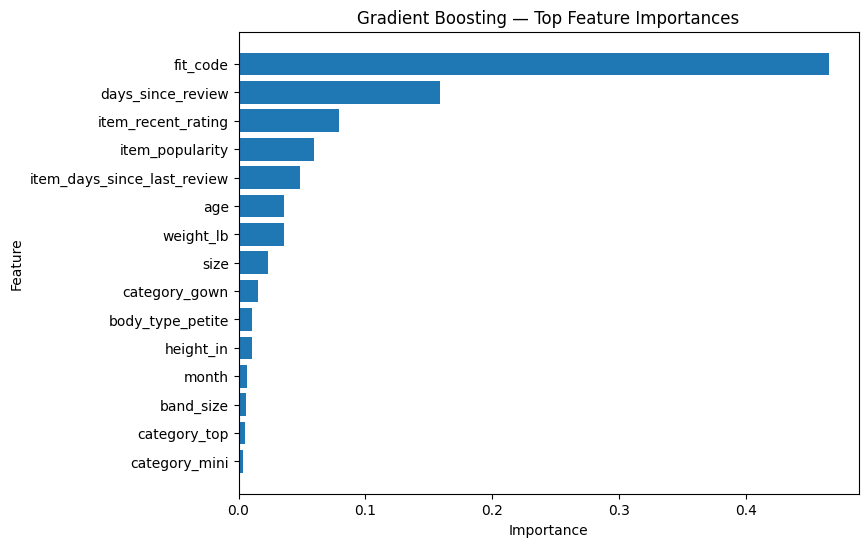

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top 15 features
importance = gbr.feature_importances_
indices = np.argsort(importance)[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importance[indices], align="center")
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.title("Gradient Boosting — Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Gradient Boosting Top Features**

The graph highlights the most influential features used by the Gradient Boosting Regressor to predict star ratings. The most dominant feature is **fit_code**, which alone accounts for a significant portion of the predictive power (around 46.6% importance). This underscores the critical finding that whether an item fits properly (small, fit, or large) is the primary determinant of a user's rating.

Following fit_code, temporal features play a crucial role:
* **item_days_since_last_review** (around 15.9% importance) indicates that the recency of an item's last review strongly influences predictions.
*   **days_since_review** (around 7.9% importance) reflects the importance of the individual review's age.


*  **item popularity** (around 5.9% importance) and item_recent_rating (around 4.9% importance) also contribute significantly, showing that an item's overall review volume and its latest rating are important signals.





# Model Conclusion
The progression from Linear Regression to Gradient Boosting and finally to Ridge Regression (with textual features) clearly shows that increasing model complexity and enriching the feature set, particularly with textual data, progressively improves prediction accuracy. While Gradient Boosting was effective with structured features, the unique insights from user reviews, captured by TF-IDF, were crucial for achieving the highest predictive power for star ratings in this dataset.


1. Linear Regression (Metadata + Temporal Features Only):

* RMSE: 0.7079
* MAE: 0.5722

Comparison: This was our simplest personalized model. It significantly improved upon the global mean baseline by leveraging structured user and item metadata, along with temporal signals. Its performance indicates that even basic linear relationships within these features capture a good portion of the rating variance. It served as a solid baseline for more complex models.

2. Gradient Boosting Regressor (Metadata + Temporal Features Only):

* RMSE: 0.6744
* MAE: 0.5277

Comparison: Outperforming the Linear Regression model, Gradient Boosting showed that a more sophisticated, non-linear approach can extract additional value from the same set of metadata and temporal features. The lower RMSE and MAE suggest it captured more intricate patterns and interactions, making it a stronger predictor without even considering textual data.

3. Ridge Regression (Metadata + Temporal + TF-IDF Features):



*   RMSE: 0.5436
*   MAE: 0.4124

Comparison: This model achieved the best performance by a significant margin. It surpassed both Linear Regression and Gradient Boosting, primarily due to the incorporation of TF-IDF features from the review text. While the Gradient Boosting model excelled with structured data, the Ridge Regression model demonstrated that adding the rich semantic information from textual reviews, even with a linear regularization technique, leads to a much more accurate prediction. This highlights that for this dataset, a comprehensive feature set including text is paramount for optimal performance.


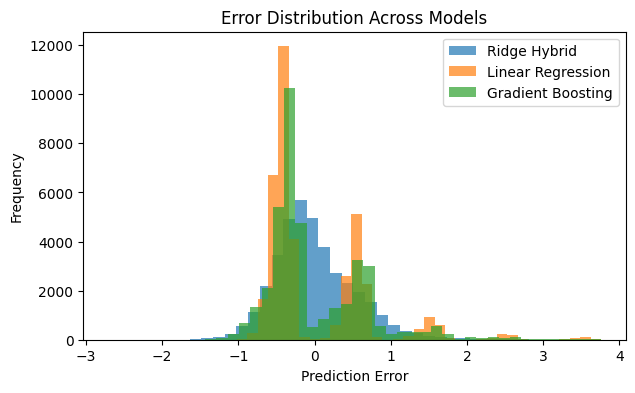

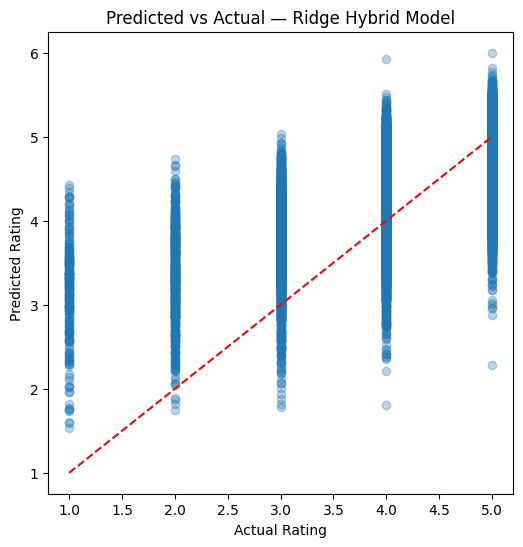

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(7,4))
plt.hist(preds_ridge_temporal - y_test, bins=40, alpha=0.7, label="Ridge Hybrid")
plt.hist(preds_lr - y_test, bins=40, alpha=0.7, label="Linear Regression")
plt.hist(preds_gbr - y_test, bins=40, alpha=0.7, label="Gradient Boosting")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution Across Models")
plt.legend()
plt.show()
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds_ridge_temporal, alpha=0.3)
plt.plot([1,5],[1,5],'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs Actual — Ridge Hybrid Model")
plt.show()

**Error Distribution Across Models**

The 'Error Distribution Across Models' plot effectively demonstrates that the Ridge Hybrid model (combining metadata, temporal features, and TF-IDF from review text) produces the most accurate predictions. Its error distribution is the narrowest and most centered around zero, indicating fewer and smaller prediction errors compared to the Linear Regression and Gradient Boosting models. This visual evidence supports the Ridge Hybrid model's superior performance in predicting star ratings.

**Predicted vs Actual — Ridge Hybrid Model**

The 'Predicted vs Actual — Ridge Hybrid Model' plot is a scatter plot comparing your model's predicted star ratings against the true, actual star ratings. Ideally, all points would fall perfectly on the red dashed diagonal line (where Predicted = Actual). The closer the points cluster to this line, the more accurate your model's predictions are. For the Ridge Hybrid model, you should observe a tight clustering of points around this diagonal, indicating strong predictive performance and minimal deviation between predicted and actual ratings.